# CRISPR-MTL — Exploratory Data Analysis

This notebook explores the three benchmark datasets used by CRISPR-MTL and
produces the figures referenced in the report. The datasets are:

1. **On-target (Doench 2016)** — 5,310 guide RNAs with a continuous cutting
   efficiency label in [0, 1]. Used for the regression head.
2. **Off-target — DeepCRISPR benchmark** — gRNA/DNA pairs with a binary
   cleavage label.
3. **Off-target — Listgarten GUIDE-seq** — additional gRNA/DNA pairs, merged
   with DeepCRISPR into a single off-target corpus for the classification head.

The analysis motivates three downstream modeling choices: class weighting and
the AUPR caveat (extreme imbalance), grouped cross-validation (very few unique
gRNAs), and the interpretability analysis (seed-region biology).

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# Make src importable and load the project config (notebook runs from notebooks/).
sys.path.insert(0, "..")
from src.dataset import load_ontarget, load_offtarget, seq_to_kmer

config = yaml.safe_load(open("../configs/config.yaml"))

# Consistent, muted plotting style across all figures.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.titleweight"] = "bold"

# Muted, colorblind-friendly palette reused throughout.
PALETTE = sns.color_palette("muted")
NUC_COLORS = {"A": "#4C72B0", "C": "#55A868", "G": "#C44E52", "T": "#8172B3"}
POS_COLOR = "#C44E52"   # positive / minority class
NEG_COLOR = "#4C72B0"   # negative / majority class

# Output directory for figures (resolve relative to project root).
FIG_DIR = Path("..") / config["paths"]["figures_dir"]
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved to: {FIG_DIR.resolve()}")

Figures will be saved to: C:\Users\Syauqi Nabil\research\team\CRISPR-MTL\outputs\figures


In [4]:
# Load all three datasets via the actual src.dataset functions.
# Paths in config are relative to the project root, so prepend "..".
df_on = load_ontarget("../" + config["paths"]["ontarget_csv"])
off = load_offtarget(
    "../" + config["paths"]["offtarget_dc"],
    "../" + config["paths"]["offtarget_lg"],
)
df_off = off["df"]
w_pos = off["w_pos"]

print("=" * 60)
print("ON-TARGET")
print("=" * 60)
print(f"shape   : {df_on.shape}")
print(f"columns : {list(df_on.columns)}")
print(f"label   : min={df_on['label'].min():.4f}  max={df_on['label'].max():.4f}  "
      f"mean={df_on['label'].mean():.4f}  median={df_on['label'].median():.4f}")
print(df_on.head(3).to_string())

print()
print("=" * 60)
print("OFF-TARGET (merged: DeepCRISPR + Listgarten)")
print("=" * 60)
n_pos = int((df_off["label"] == 1).sum())
n_neg = int((df_off["label"] == 0).sum())
print(f"shape       : {df_off.shape}")
print(f"columns     : {list(df_off.columns)}")
print(f"positives   : {n_pos}")
print(f"negatives   : {n_neg}")
print(f"imbalance   : 1 positive per {n_neg / n_pos:.1f} negatives  (w_pos = {w_pos:.2f})")
print(f"unique gRNAs: {df_off['grna'].nunique()}")
print(df_off.head(3).to_string())

ON-TARGET
shape   : (5310, 2)
columns : ['grna_23mer', 'label']
label   : min=0.0000  max=0.8781  mean=0.5024  median=0.5190
                grna_23mer     label
0  AAAAAAAACACTGCAACAAGAGG  0.544412
1  AAAAAACCTACCGTAAACTCGGG  0.617512
2  AAAAAGCAGCGTCAGTGGATTGG  0.476232

OFF-TARGET (merged: DeepCRISPR + Listgarten)
shape       : (10221, 3)
columns     : ['grna', 'dna_target', 'label']
positives   : 53
negatives   : 10168
imbalance   : 1 positive per 191.8 negatives  (w_pos = 191.85)
unique gRNAs: 23
                      grna               dna_target  label
0  AAATGAGAAGAAGAGGCACAGGG  GCATGAGAAGAAGAGACATAGCC      0
1  AAATGAGAAGAAGAGGCACAGGG  GAAGAAGAAGAAGAGGAAGAGGA      0
2  TGACATCAATTATTATACATCGG  TGTCATCAATTATTAGGATTCGT      0


## On-Target Dataset

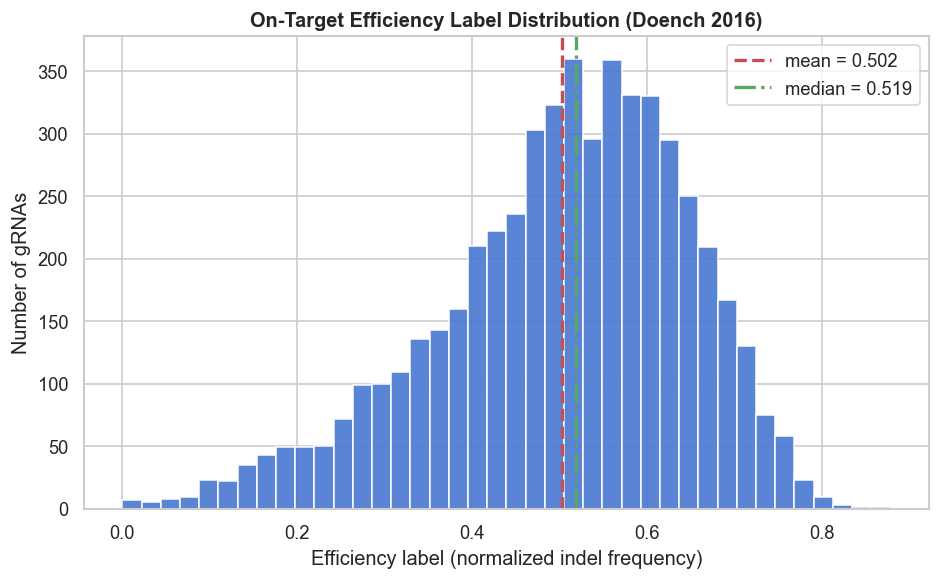

In [5]:
# On-target label (efficiency) distribution with mean / median annotated.
labels = df_on["label"].values
mean_v = labels.mean()
median_v = np.median(labels)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(labels, bins=40, color=PALETTE[0], edgecolor="white", alpha=0.9)
ax.axvline(mean_v, color=POS_COLOR, linestyle="--", linewidth=2,
           label=f"mean = {mean_v:.3f}")
ax.axvline(median_v, color="#55A868", linestyle="-.", linewidth=2,
           label=f"median = {median_v:.3f}")
ax.set_title("On-Target Efficiency Label Distribution (Doench 2016)")
ax.set_xlabel("Efficiency label (normalized indel frequency)")
ax.set_ylabel("Number of gRNAs")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_ontarget_dist.png", bbox_inches="tight")
plt.show()

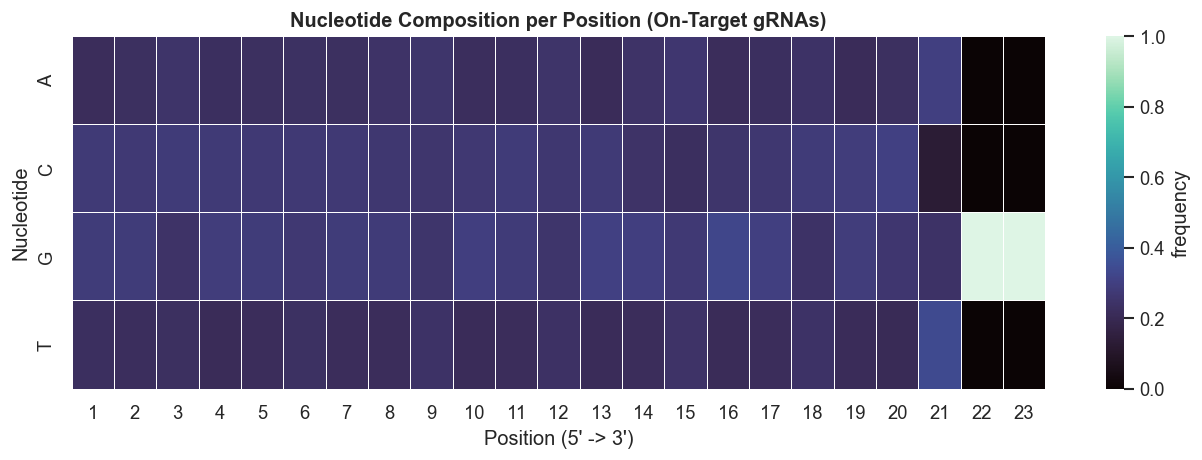

In [6]:
# Nucleotide composition per position: A/C/G/T frequency at each of 23 positions.
positions = 23
nucs = ["A", "C", "G", "T"]
comp = np.zeros((len(nucs), positions))  # rows = nucleotide, cols = position

seqs = df_on["grna_23mer"].values
for s in seqs:
    for i in range(positions):
        nt = s[i]
        if nt in NUC_COLORS:
            comp[nucs.index(nt), i] += 1
comp /= len(seqs)  # convert counts to per-position frequency

fig, ax = plt.subplots(figsize=(11, 4))
im = sns.heatmap(
    comp, ax=ax, cmap="mako",
    xticklabels=[str(i + 1) for i in range(positions)],
    yticklabels=nucs,
    cbar_kws={"label": "frequency"},
    vmin=0.0, vmax=comp.max(),
    linewidths=0.3, linecolor="white",
)
ax.set_title("Nucleotide Composition per Position (On-Target gRNAs)")
ax.set_xlabel("Position (5' -> 3')")
ax.set_ylabel("Nucleotide")
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_nucleotide_composition.png", bbox_inches="tight")
plt.show()

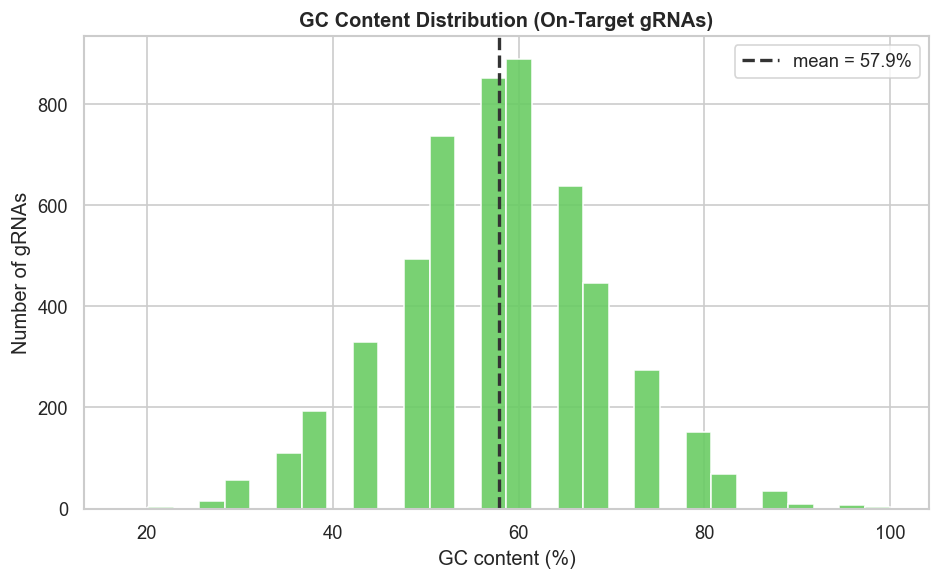

In [7]:
# GC content distribution: GC% per gRNA.
def gc_percent(seq: str) -> float:
    return 100.0 * (seq.count("G") + seq.count("C")) / len(seq)

gc = df_on["grna_23mer"].apply(gc_percent).values
gc_mean = gc.mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(gc, bins=30, color=PALETTE[2], edgecolor="white", alpha=0.9)
ax.axvline(gc_mean, color="#333333", linestyle="--", linewidth=2,
           label=f"mean = {gc_mean:.1f}%")
ax.set_title("GC Content Distribution (On-Target gRNAs)")
ax.set_xlabel("GC content (%)")
ax.set_ylabel("Number of gRNAs")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_gc_content.png", bbox_inches="tight")
plt.show()

## Off-Target Dataset

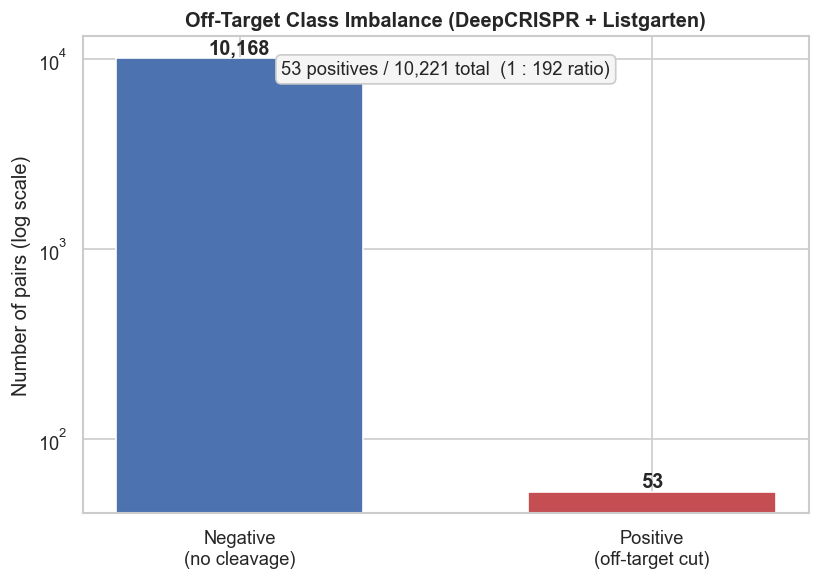

In [8]:
# Class imbalance: positive vs negative counts, annotated with exact numbers.
counts = [n_neg, n_pos]
labels_bar = [f"Negative\n(no cleavage)", f"Positive\n(off-target cut)"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels_bar, counts, color=[NEG_COLOR, POS_COLOR],
              edgecolor="white", width=0.6)
ax.set_yscale("log")  # log scale so the 53 positives are visible next to 10k+ negatives
ax.set_title("Off-Target Class Imbalance (DeepCRISPR + Listgarten)")
ax.set_ylabel("Number of pairs (log scale)")
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, c, f"{c:,}",
            ha="center", va="bottom", fontweight="bold")
ax.text(
    0.5, 0.92,
    f"{n_pos} positives / {n_pos + n_neg:,} total  "
    f"(1 : {n_neg / n_pos:.0f} ratio)",
    transform=ax.transAxes, ha="center",
    fontsize=11, bbox=dict(boxstyle="round", fc="#f5f5f5", ec="#cccccc"),
)
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_class_imbalance.png", bbox_inches="tight")
plt.show()

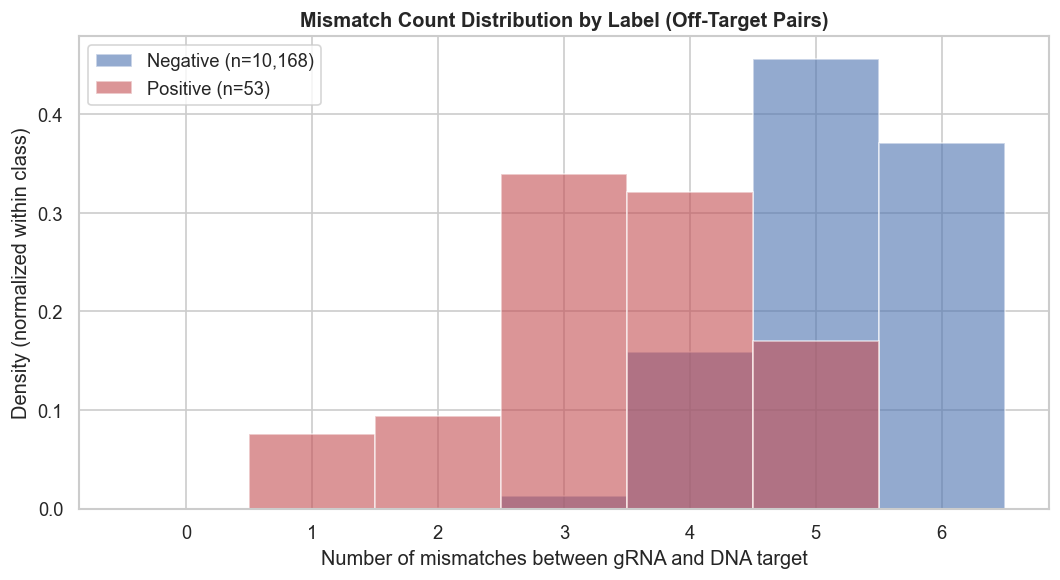

In [9]:
# Mismatch analysis: number of mismatches between each gRNA and its DNA target,
# split by label. Both sequences are aligned 23-mers.
def count_mismatches(g: str, d: str) -> int:
    n = min(len(g), len(d))
    return sum(1 for i in range(n) if g[i] != d[i])

df_off = df_off.copy()
df_off["n_mismatch"] = [count_mismatches(g, d)
                        for g, d in zip(df_off["grna"], df_off["dna_target"])]

# Normalized proportion within each class so the rare positives stay visible.
max_mm = int(df_off["n_mismatch"].max())
bins = np.arange(0, max_mm + 2) - 0.5
pos_mm = df_off.loc[df_off["label"] == 1, "n_mismatch"]
neg_mm = df_off.loc[df_off["label"] == 0, "n_mismatch"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(neg_mm, bins=bins, density=True, alpha=0.6, color=NEG_COLOR,
        edgecolor="white", label=f"Negative (n={len(neg_mm):,})")
ax.hist(pos_mm, bins=bins, density=True, alpha=0.6, color=POS_COLOR,
        edgecolor="white", label=f"Positive (n={len(pos_mm)})")
ax.set_title("Mismatch Count Distribution by Label (Off-Target Pairs)")
ax.set_xlabel("Number of mismatches between gRNA and DNA target")
ax.set_ylabel("Density (normalized within class)")
ax.set_xticks(range(0, max_mm + 1))
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_mismatch_distribution.png", bbox_inches="tight")
plt.show()

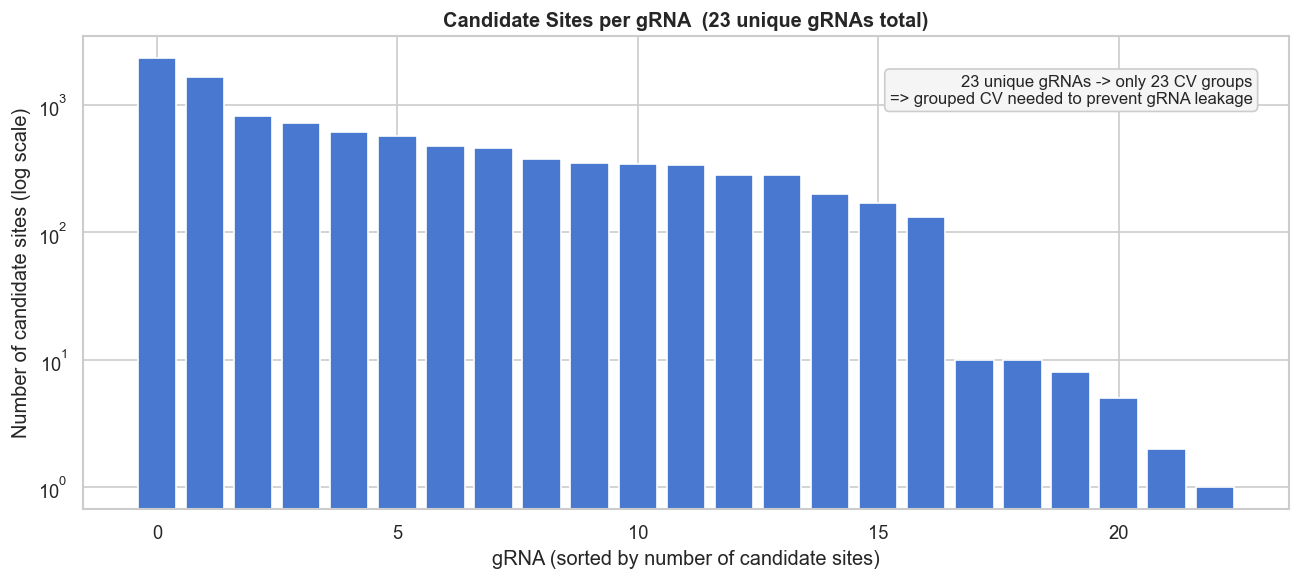

In [10]:
# gRNA group structure: how many unique gRNAs, and how many candidate sites each
# has. Very few groups motivates StratifiedGroupKFold (grouped by gRNA) to keep
# the same guide out of both train and validation folds.
grna_counts = df_off["grna"].value_counts().sort_values(ascending=False)
n_unique = len(grna_counts)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(n_unique), grna_counts.values, color=PALETTE[0],
       edgecolor="white")
ax.set_yscale("log")
ax.set_title(f"Candidate Sites per gRNA  ({n_unique} unique gRNAs total)")
ax.set_xlabel("gRNA (sorted by number of candidate sites)")
ax.set_ylabel("Number of candidate sites (log scale)")
ax.text(
    0.97, 0.92,
    f"{n_unique} unique gRNAs -> only {n_unique} CV groups\n"
    f"=> grouped CV needed to prevent gRNA leakage",
    transform=ax.transAxes, ha="right", va="top",
    fontsize=10, bbox=dict(boxstyle="round", fc="#f5f5f5", ec="#cccccc"),
)
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_grna_groups.png", bbox_inches="tight")
plt.show()

## Tokenization Example

DNABERT consumes overlapping 6-mers. A 23-mer gRNA produces 18 tokens, which
with [CLS] and [SEP] becomes a 20-token input for the on-target head.

In [11]:
# Show seq_to_kmer output for three sample gRNAs.
samples = df_on["grna_23mer"].head(3).tolist()
for i, s in enumerate(samples, 1):
    kmers = seq_to_kmer(s, k=config["data"]["kmer_k"])
    n_tokens = len(kmers.split())
    print(f"Sample {i}")
    print(f"  sequence ({len(s)} nt) : {s}")
    print(f"  6-mer tokens ({n_tokens}): {kmers}")
    print(f"  DNABERT input        : [CLS] {kmers} [SEP]  -> {n_tokens + 2} tokens")
    print()

Sample 1
  sequence (23 nt) : AAAAAAAACACTGCAACAAGAGG
  6-mer tokens (18): AAAAAA AAAAAA AAAAAA AAAAAC AAAACA AAACAC AACACT ACACTG CACTGC ACTGCA CTGCAA TGCAAC GCAACA CAACAA AACAAG ACAAGA CAAGAG AAGAGG
  DNABERT input        : [CLS] AAAAAA AAAAAA AAAAAA AAAAAC AAAACA AAACAC AACACT ACACTG CACTGC ACTGCA CTGCAA TGCAAC GCAACA CAACAA AACAAG ACAAGA CAAGAG AAGAGG [SEP]  -> 20 tokens

Sample 2
  sequence (23 nt) : AAAAAACCTACCGTAAACTCGGG
  6-mer tokens (18): AAAAAA AAAAAC AAAACC AAACCT AACCTA ACCTAC CCTACC CTACCG TACCGT ACCGTA CCGTAA CGTAAA GTAAAC TAAACT AAACTC AACTCG ACTCGG CTCGGG
  DNABERT input        : [CLS] AAAAAA AAAAAC AAAACC AAACCT AACCTA ACCTAC CCTACC CTACCG TACCGT ACCGTA CCGTAA CGTAAA GTAAAC TAAACT AAACTC AACTCG ACTCGG CTCGGG [SEP]  -> 20 tokens

Sample 3
  sequence (23 nt) : AAAAAGCAGCGTCAGTGGATTGG
  6-mer tokens (18): AAAAAG AAAAGC AAAGCA AAGCAG AGCAGC GCAGCG CAGCGT AGCGTC GCGTCA CGTCAG GTCAGT TCAGTG CAGTGG AGTGGA GTGGAT TGGATT GGATTG GATTGG
  DNABERT input        : [CLS] AAAAAG AAA